In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load Togo dataset
df = pd.read_csv(r"C:\Users\Lidiya Getale\Downloads\data\data\togo-dapaong_qc.csv")

In [2]:

# Inspect data
print(df.head())
print(df.info())
print(df.describe())

# Missing values
print(df.isna().sum())
missing_cols = df.columns[df.isna().sum()/len(df) > 0.05]
print("Columns with >5% missing:", missing_cols.tolist())


          Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-10-25 00:01 -1.3  0.0  0.0   0.0   0.0  24.8  94.5  0.9     1.1   
1  2021-10-25 00:02 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.1     1.6   
2  2021-10-25 00:03 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.2     1.4   
3  2021-10-25 00:04 -1.2  0.0  0.0   0.0   0.0  24.8  94.3  1.2     1.6   
4  2021-10-25 00:05 -1.2  0.0  0.0   0.0   0.0  24.8  94.0  1.3     1.6   

   WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  TModA  TModB  \
0      0.4  227.6      1.1  977         0            0.0   24.7   24.4   
1      0.4  229.3      0.7  977         0            0.0   24.7   24.4   
2      0.3  228.5      2.9  977         0            0.0   24.7   24.4   
3      0.3  229.1      4.6  977         0            0.0   24.7   24.4   
4      0.4  227.5      1.6  977         0            0.0   24.7   24.4   

   Comments  
0       NaN  
1       NaN  
2       NaN  
3       NaN  
4       NaN  
<class 'pandas.core.

In [3]:
# Handle missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)
df.drop(columns=missing_cols, inplace=True)


C:\Users\Lidiya Getale\AppData\Local\Temp\ipykernel_880\3515467716.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Lidiya Getale\AppData\Local\Temp\ipykernel_880\3515467716.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [4]:
# Outlier detection
numeric_cols = df.select_dtypes(include=np.number).columns
z_scores = np.abs(stats.zscore(df[numeric_cols]))
outliers = (z_scores > 3).any(axis=1)
print("Number of rows with outliers:", outliers.sum())


Number of rows with outliers: 20178


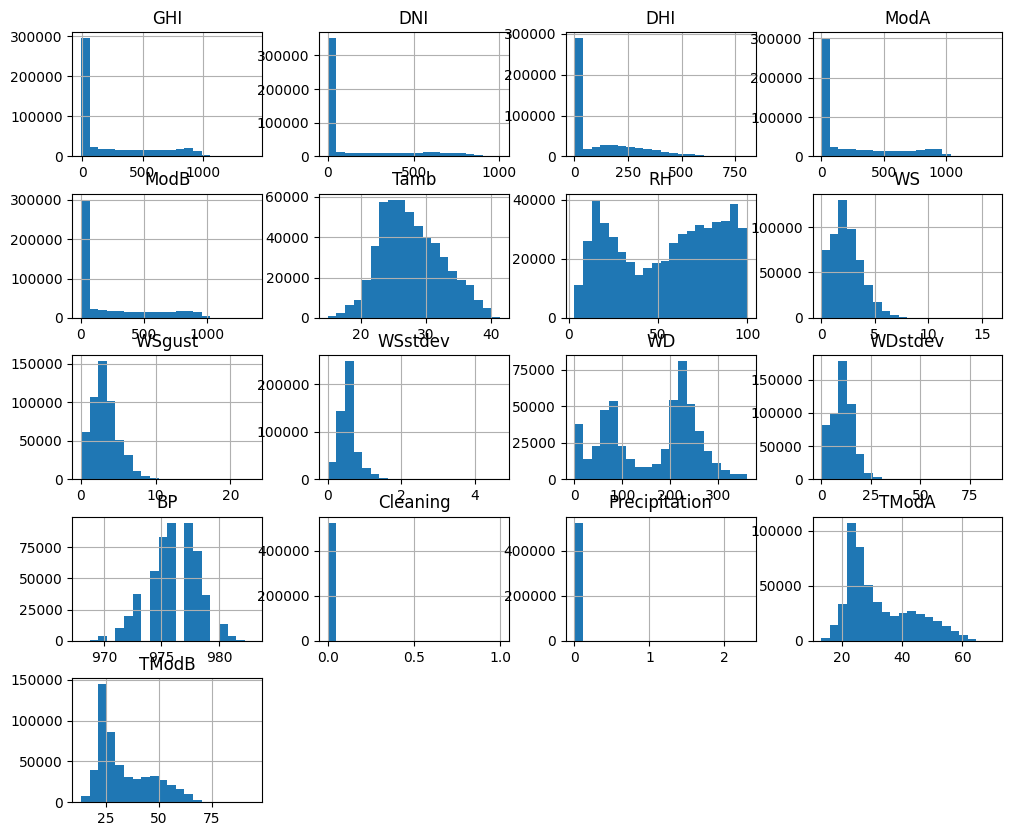

ValueError: could not convert string to float: '2021-10-25 00:01'

<Figure size 1000x800 with 0 Axes>

: 

In [ ]:

# Visualizations with red mean lines
numeric_cols = df.select_dtypes(include='number').columns.tolist()
if not numeric_cols:
    print("No numeric columns found to visualize.")
else:
    # Histograms with red dashed mean lines
    ax_dict = df[numeric_cols].hist(figsize=(12,10), bins=20)
    # ax_dict can be array of axes or dict-like depending on pandas version
    try:
        axes = ax_dict.flatten()
    except Exception:
        axes = [ax_dict] if not hasattr(ax_dict, 'flatten') else list(ax_dict)
    for i, col in enumerate(numeric_cols):
        try:
            ax = axes[i]
            mean_val = df[col].mean()
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=1)
        except Exception:
            pass
    plt.tight_layout()
    plt.show()

    # Correlation heatmap (numeric columns only)
    plt.figure(figsize=(10,8))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlation Heatmap (numeric columns)')
    plt.show()

    # Horizontal boxplots for numeric columns with red mean lines
    plt.figure(figsize=(12,8))
    sns.boxplot(data=df[numeric_cols], orient='h')
    # draw red vertical lines at means
    means = df[numeric_cols].mean()
    for j, col in enumerate(numeric_cols):
        plt.axvline(means[col], color='red', linestyle='--', linewidth=1)
    plt.title('Boxplots of numeric columns')
    plt.tight_layout()
    plt.show()